In [7]:
import pandas as pd
import h5py
import numpy as np
from datetime import timedelta

# --- 1. KONFIGURASI PATH ---
CSV_STEAD = "/Volumes/Local Disk/Code_Git/S3_code/seismic/data/merge.csv"
H5_STEAD  = "/Volumes/Local Disk/Code_Git/S3_code/seismic/data/merge.hdf5"
PATH_USGS = '/Volumes/Extreme SSD/benchmark_bmkg_indonesia/usgs_katalog/katalog_usgs_master_2001_2025.csv'
PATH_BMKG = '/Volumes/Extreme SSD/Indonesian Earthquake Catalog (BMKG), 1998–2024/BMKG_Earthquake_Catalog.csv'

# --- 2. DEFINISI RC BOUNDARIES ---
rc_data = {
    'RC_Code': ['RC_01', 'RC_02', 'RC_03', 'RC_04', 'RC_05', 'RC_06', 'RC_07', 'RC_08', 'RC_09', 'RC_10'],
    'Lat_Min': [0.5, 3.0, 7.0, 0.0, 6.0, 1.0, 0.0, 7.0, 0.0, 0.5],
    'Lat_Max': [6.0, 14.0, 14.0, 7.5, 7.5, 3.5, 14.0, 14.0, 7.5, 6.0],
    'Lon_Min': [92.0, 92.0, 113.5, 113.5, 132.0, 92.0, 108.5, 122.0, 123.5, 108.5],
    'Lon_Max': [109.0, 109.0, 122.5, 124.0, 141.0, 109.0, 114.0, 141.0, 132.5, 132.5]
}
df_rc = pd.DataFrame(rc_data)

# --- 3. FUNGSI HELPER ---
def assign_rc(lat, lon, df_rc_ref):
    """Menentukan kode RC berdasarkan koordinat latitude & longitude."""
    matched = [row['RC_Code'] for _, row in df_rc_ref.iterrows() 
               if (row['Lat_Min'] <= lat <= row['Lat_Max']) and (row['Lon_Min'] <= lon <= row['Lon_Max'])]
    return ",".join(matched) if matched else "Outside"

def match_events(df_base, df_ref, label_ref):
    """Mencari kecocokan event berdasarkan waktu (toleransi 60 detik)."""
    results = []
    # Loop untuk 500 data pertama agar proses tidak terlalu lama (bisa disesuaikan)
    for _, s_row in df_base.head(500).iterrows():
        t_start = s_row['origin_time'] - timedelta(seconds=60)
        t_end   = s_row['origin_time'] + timedelta(seconds=60)
        
        matches = df_ref[(df_ref['datetime'] >= t_start) & (df_ref['datetime'] <= t_end)]
        
        for _, r_row in matches.iterrows():
            results.append({
                'trace_name': s_row['trace_name'],
                'rc': s_row['assigned_rc'],
                'mag_stead': s_row['source_magnitude'],
                f'mag_{label_ref}': r_row['mag'],
                'diff_mag': s_row['source_magnitude'] - r_row['mag']
            })
    return pd.DataFrame(results)


# --- 4. PROSES EKSEKUSI ---

# A. Load & Filter STEAD
print("Memuat data STEAD...")
df_stead = pd.read_csv(CSV_STEAD)

# Perbaikan: Menggunakan nama kolom yang benar sesuai hasil print-mu
# Kita ubah namanya secara global agar konsisten dengan fungsi matching kita
df_stead.rename(columns={'source_origin_time': 'origin_time'}, inplace=True)

# Konversi ke datetime
df_stead['origin_time'] = pd.to_datetime(df_stead['origin_time'])

# Filter menggunakan nama kolom yang tepat
df_nf = df_stead[
    (df_stead['trace_category'] == "earthquake_local") &
    (df_stead['source_distance_km'] <= 20) &
    (df_stead['source_magnitude'] >= 3.0)
].copy().reset_index(drop=True)

# Beri label RC pada STEAD menggunakan koordinat source
df_nf['assigned_rc'] = df_nf.apply(
    lambda x: assign_rc(x['source_latitude'], x['source_longitude'], df_rc), 
    axis=1
)

print(f"Filter selesai. Ditemukan {len(df_nf)} data yang cocok.")


# Beri label RC pada STEAD
df_nf['assigned_rc'] = df_nf.apply(lambda x: assign_rc(x['source_latitude'], x['source_longitude'], df_rc), axis=1)

# B. Load & Clean Katalog BMKG
print("Memuat data BMKG...")
df_bmkg = pd.read_csv(PATH_BMKG)

# 1. Menggabungkan Tanggal dan Waktu
# Kita gunakan nama kolom persis sesuai hasil print-mu
try:
    df_bmkg['datetime'] = pd.to_datetime(df_bmkg['Date'] + ' ' + df_bmkg['Time (UTC)'])
except Exception as e:
    print(f"Gagal menggabungkan waktu: {e}")
    # Backup: jika ada format aneh, kita coba konversi paksa
    df_bmkg['datetime'] = pd.to_datetime(df_bmkg['Date'].astype(str) + ' ' + df_bmkg['Time (UTC)'].astype(str), errors='coerce')

# 2. Standarisasi Nama Kolom
# Kita ubah agar sesuai dengan fungsi match_events (mag, latitude, longitude)
rename_map_bmkg = {
    'Magnitude': 'mag',
    'Latitude': 'latitude',
    'Longitude': 'longitude',
    'Depth (km)': 'depth'
}
df_bmkg.rename(columns=rename_map_bmkg, inplace=True)

# 3. Membersihkan data yang gagal konversi waktu (jika ada)
df_bmkg = df_bmkg.dropna(subset=['datetime'])

print(f"Katalog BMKG siap. Total: {len(df_bmkg)} event.")

# C. Load & Clean Katalog USGS
print("Memuat data USGS...")
df_usgs = pd.read_csv(PATH_USGS)

# Gunakan format ISO8601 dan paksa menjadi UTC agar konsisten
try:
    df_usgs['datetime'] = pd.to_datetime(df_usgs['time'], format='ISO8601', utc=True)
except Exception:
    # Jika versi Pandas kamu lama, gunakan cara ini:
    df_usgs['datetime'] = pd.to_datetime(df_usgs['time'], utc=True)

# Penting: Hilangkan info timezone agar bisa dibandingkan dengan katalog lain yang non-timezone
df_usgs['datetime'] = df_usgs['datetime'].dt.tz_localize(None)

print(f"Katalog USGS siap. Total: {len(df_usgs)} event.")

# D. Investigasi (Matching)
print("Sedang menginvestigasi kecocokan data...")
res_bmkg = match_events(df_nf, df_bmkg, "bmkg")
res_usgs = match_events(df_nf, df_usgs, "usgs")

# --- 5. OUTPUT ---
print("\n--- RINGKASAN INVESTIGASI ---")
print(f"Total STEAD Terfilter: {len(df_nf)}")
print(f"Kecocokan dengan BMKG: {len(res_bmkg)} event")
print(f"Kecocokan dengan USGS: {len(res_usgs)} event")

if not res_bmkg.empty:
    print("\nContoh Perbandingan Magnitudo (STEAD vs BMKG):")
    print(res_bmkg[['trace_name', 'rc', 'mag_stead', 'mag_bmkg', 'diff_mag']].head())

# --- 6. INVESTIGASI KOORDINAT & SEBARAN ---

print("\n--- Analisis Sebaran Geografis STEAD Terfilter ---")
# Cek rentang koordinat di data STEAD yang sudah difilter
lat_min, lat_max = df_nf['source_latitude'].min(), df_nf['source_latitude'].max()
lon_min, lon_max = df_nf['source_longitude'].min(), df_nf['source_longitude'].max()

print(f"Rentang Latitude STEAD : {lat_min} s/d {lat_max}")
print(f"Rentang Longitude STEAD: {lon_min} s/d {lon_max}")

# Cek 5 stasiun pertama untuk melihat lokasi sensor
print("\nContoh Lokasi Sensor (Receiver):")
print(df_nf[['receiver_code', 'receiver_latitude', 'receiver_longitude']].head())

# --- 7. REVISI FUNGSI MATCHING (Opsional) ---
# Jika ingin mencari gempa Indonesia saja di STEAD:
df_indo = df_nf[
    (df_nf['source_latitude'] >= -11) & (df_nf['source_latitude'] <= 6) &
    (df_nf['source_longitude'] >= 95) & (df_nf['source_longitude'] <= 141)
]
print(f"\nJumlah data STEAD yang benar-benar di wilayah Indonesia: {len(df_indo)}")

Memuat data STEAD...


/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_67692/468338772.py:54: DtypeWarning: Columns (7,11,13,14,24,25,26,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df_stead = pd.read_csv(CSV_STEAD)


Filter selesai. Ditemukan 2515 data yang cocok.
Memuat data BMKG...
Katalog BMKG siap. Total: 217807 event.
Memuat data USGS...
Katalog USGS siap. Total: 83045 event.
Sedang menginvestigasi kecocokan data...

--- RINGKASAN INVESTIGASI ---
Total STEAD Terfilter: 2515
Kecocokan dengan BMKG: 14 event
Kecocokan dengan USGS: 7 event

Contoh Perbandingan Magnitudo (STEAD vs BMKG):
                 trace_name       rc  mag_stead  mag_bmkg  diff_mag
0  AKH.GO_20140309113129_EV  Outside        3.3       4.4      -1.1
1  AKH.GO_20140309113132_EV  Outside        3.3       4.4      -1.1
2  AQU.MN_20090407041228_EV  Outside        3.0       3.3      -0.3
3  AQU.MN_20090410154612_EV  Outside        3.4       3.1       0.3
4  AQU.MN_20090413133558_EV  Outside        3.8       5.1      -1.3

--- Analisis Sebaran Geografis STEAD Terfilter ---
Rentang Latitude STEAD : -41.457 s/d 65.1617
Rentang Longitude STEAD: -177.9559 s/d 179.2752

Contoh Lokasi Sensor (Receiver):
  receiver_code  receiver_latitude 

In [8]:
import pandas as pd
from datetime import timedelta
import numpy as np

# --- 1. LOAD DATA ---
# (Pastikan path tetap sama seperti sebelumnya)
df_stead = pd.read_csv(CSV_STEAD)
df_bmkg = pd.read_csv(PATH_BMKG)
df_usgs = pd.read_csv(PATH_USGS)

# --- 2. STANDARISASI WAKTU ---
df_stead['origin_time'] = pd.to_datetime(df_stead['source_origin_time'])

# BMKG: Menggunakan kolom 'Time (UTC)' yang kita temukan tadi
df_bmkg['datetime'] = pd.to_datetime(df_bmkg['Date'] + ' ' + df_bmkg['Time (UTC)'], errors='coerce')

# USGS: Menggunakan format ISO8601
df_usgs['datetime'] = pd.to_datetime(df_usgs['time'], format='ISO8601', utc=True).dt.tz_localize(None)

# Bersihkan data yang gagal konversi waktu
df_bmkg = df_bmkg.dropna(subset=['datetime'])
df_usgs = df_usgs.dropna(subset=['datetime'])

# --- 3. FUNGSI MATCHING MURNI (KOORDINAT & WAKTU) ---
def pure_match(df_base, df_ref, label, time_tol=60, dist_tol=2.0):
    """
    time_tol: Toleransi waktu dalam detik
    dist_tol: Toleransi jarak dalam derajat (Lat/Lon)
    """
    matched_data = []
    
    # Kita ambil sampel 1000 data STEAD untuk investigasi cepat
    for _, s in df_base.head(1000).iterrows():
        t_min = s['origin_time'] - timedelta(seconds=time_tol)
        t_max = s['origin_time'] + timedelta(seconds=time_tol)
        
        # Filter berdasarkan Waktu DAN Koordinat (Bounding Box sederhana)
        matches = df_ref[
            (df_ref['datetime'] >= t_min) & (df_ref['datetime'] <= t_max) &
            (df_ref['latitude'].between(s['source_latitude'] - dist_tol, s['source_latitude'] + dist_tol)) &
            (df_ref['longitude'].between(s['source_longitude'] - dist_tol, s['source_longitude'] + dist_tol))
        ]
        
        for _, r in matches.iterrows():
            matched_data.append({
                'trace_name': s['trace_name'],
                'network': s['network_code'],
                'stead_mag': s['source_magnitude'],
                f'{label}_mag': r['mag'] if 'mag' in r else r['Magnitude'],
                'dist_diff': np.sqrt((s['source_latitude']-r['latitude'])**2 + (s['source_longitude']-r['longitude'])**2)
            })
            
    return pd.DataFrame(matched_data)

# --- 4. EKSEKUSI ---
print("Memulai investigasi murni...")
res_usgs_pure = pure_match(df_stead, df_usgs, "usgs")
res_bmkg_pure = pure_match(df_stead, df_bmkg, "bmkg")

print(f"\nHasil Investigasi:")
print(f"Kecocokan dengan USGS: {len(res_usgs_pure)} data")
print(f"Kecocokan dengan BMKG: {len(res_bmkg_pure)} data")

if not res_usgs_pure.empty:
    print("\nSampel Kecocokan USGS:")
    print(res_usgs_pure.head())

/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_67692/1130014431.py:7: DtypeWarning: Columns (7,11,13,14,24,25,26,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df_stead = pd.read_csv(CSV_STEAD)


Memulai investigasi murni...


KeyError: 'latitude'

In [3]:
def pure_match(df_base, df_ref, label, time_tol=60, dist_tol=2.0):
    matched_data = []
    
    # Deteksi otomatis nama kolom koordinat di df_ref
    lat_col = 'latitude' if 'latitude' in df_ref.columns else 'Latitude'
    lon_col = 'longitude' if 'longitude' in df_ref.columns else 'Longitude'
    mag_col = 'mag' if 'mag' in df_ref.columns else ('Magnitude' if 'Magnitude' in df_ref.columns else 'magnitude')

    print(f"Investigasi {label}: Menggunakan kolom {lat_col}, {lon_col}, {mag_col}")

    # Ambil sampel 1000 data STEAD (df_base)
    for _, s in df_base.head(1000).iterrows():
        t_min = s['origin_time'] - timedelta(seconds=time_tol)
        t_max = s['origin_time'] + timedelta(seconds=time_tol)
        
        # Filter berdasarkan Waktu DAN Koordinat
        matches = df_ref[
            (df_ref['datetime'] >= t_min) & (df_ref['datetime'] <= t_max) &
            (df_ref[lat_col].between(s['source_latitude'] - dist_tol, s['source_latitude'] + dist_tol)) &
            (df_ref[lon_col].between(s['source_longitude'] - dist_tol, s['source_longitude'] + dist_tol))
        ]
        
        for _, r in matches.iterrows():
            matched_data.append({
                'trace_name': s['trace_name'],
                'network': s['network_code'],
                'stead_mag': s['source_magnitude'],
                f'{label}_mag': r[mag_col],
                'dist_diff': np.sqrt((s['source_latitude']-r[lat_col])**2 + (s['source_longitude']-r[lon_col])**2)
            })
            
    return pd.DataFrame(matched_data)

# Jalankan ulang eksekusi
print("Memulai investigasi murni...")
res_usgs_pure = pure_match(df_stead, df_usgs, "usgs")
res_bmkg_pure = pure_match(df_stead, df_bmkg, "bmkg")

print(f"\nHasil Investigasi Baru:")
print(f"Kecocokan dengan USGS: {len(res_usgs_pure)} data")
print(f"Kecocokan dengan BMKG: {len(res_bmkg_pure)} data")

Memulai investigasi murni...
Investigasi usgs: Menggunakan kolom latitude, longitude, mag
Investigasi bmkg: Menggunakan kolom Latitude, Longitude, Magnitude

Hasil Investigasi Baru:
Kecocokan dengan USGS: 0 data
Kecocokan dengan BMKG: 0 data


In [4]:
import pandas as pd
import numpy as np

# --- 1. RINGKASAN KOORDINAT ---
def print_geographic_summary(df, name):
    print(f"\n--- Ringkasan Geografis {name} ---")
    print(f"Latitude  : {df['latitude'].min():.2f} s/d {df['latitude'].max():.2f}")
    print(f"Longitude : {df['longitude'].min():.2f} s/d {df['longitude'].max():.2f}")

# Menyiapkan kolom yang seragam untuk ringkasan
df_stead_geo = df_stead[['source_latitude', 'source_longitude']].rename(
    columns={'source_latitude': 'latitude', 'source_longitude': 'longitude'}
)

print_geographic_summary(df_stead_geo, "STEAD")
print_geographic_summary(df_bmkg, "BMKG")

# --- 2. INVESTIGASI JARAK TERDEKAT ---
print("\n--- Investigasi Jarak Terdekat (5 Sampel STEAD ke Katalog BMKG) ---")

for i, s in df_stead.head(5).iterrows():
    # Hitung jarak Euclidean kasar (dalam derajat) ke semua titik di BMKG
    # Rumus: sqrt((lat1-lat2)^2 + (lon1-lon2)^2)
    distances = np.sqrt(
        (df_bmkg['Latitude'] - s['source_latitude'])**2 + 
        (df_bmkg['Longitude'] - s['source_longitude'])**2
    )
    min_dist = distances.min()
    idx_min = distances.idxmin()
    
    print(f"Sampel STEAD {i} ({s['trace_name']}):")
    print(f"  - Lokasi STEAD: {s['source_latitude']}, {s['source_longitude']}")
    print(f"  - Gempa BMKG Terdekat: Jarak {min_dist:.2f} derajat")
    print(f"  - Lokasi Terdekat di BMKG: {df_bmkg.loc[idx_min, 'Latitude']}, {df_bmkg.loc[idx_min, 'Longitude']}")
    print("-" * 30)


--- Ringkasan Geografis STEAD ---
Latitude  : -43.85 s/d 78.38
Longitude : -180.00 s/d 180.00

--- Ringkasan Geografis BMKG ---


KeyError: 'latitude'

In [5]:
import pandas as pd
import numpy as np

# --- 1. MEMBERSIHKAN DATAFRAME ---
def super_clean(df):
    # Nama kolom jadi huruf kecil & buang spasi/kurung
    df.columns = [c.lower().split(' (')[0].strip() for c in df.columns]
    # BUANG baris yang koordinatnya kosong (penting agar tidak KeyError: nan)
    df = df.dropna(subset=['latitude', 'longitude'])
    return df

# Proses pembersihan
df_stead = super_clean(df_stead)
df_bmkg = super_clean(df_bmkg)

# Pastikan tipe data koordinat adalah float (angka)
df_bmkg['latitude'] = pd.to_numeric(df_bmkg['latitude'], errors='coerce')
df_bmkg['longitude'] = pd.to_numeric(df_bmkg['longitude'], errors='coerce')
df_stead['latitude'] = pd.to_numeric(df_stead['source_latitude'], errors='coerce')
df_stead['longitude'] = pd.to_numeric(df_stead['source_longitude'], errors='coerce')

# --- 2. RINGKASAN GEOGRAFIS ---
print(f"\n--- Ringkasan Geografis STEAD ---")
print(f"Lat: {df_stead['latitude'].min():.2f} s/d {df_stead['latitude'].max():.2f}")
print(f"Lon: {df_stead['longitude'].min():.2f} s/d {df_stead['longitude'].max():.2f}")

print(f"\n--- Ringkasan Geografis BMKG ---")
print(f"Lat: {df_bmkg['latitude'].min():.2f} s/d {df_bmkg['latitude'].max():.2f}")
print(f"Lon: {df_bmkg['longitude'].min():.2f} s/d {df_bmkg['longitude'].max():.2f}")

# --- 3. INVESTIGASI JARAK (Hanya jika data valid) ---
print("\n--- Investigasi Jarak Terdekat ---")

# Ambil 5 sampel pertama yang valid
sample_stead = df_stead.dropna(subset=['latitude', 'longitude']).head(5)

for i, s in sample_stead.iterrows():
    # Kalkulasi jarak
    diff_lat = df_bmkg['latitude'] - s['latitude']
    diff_lon = df_bmkg['longitude'] - s['longitude']
    distances = np.sqrt(diff_lat**2 + diff_lon**2)
    
    # Ambil nilai minimum yang bukan NaN
    valid_distances = distances.dropna()
    if not valid_distances.empty:
        min_dist = valid_distances.min()
        idx_min = valid_distances.idxmin()
        
        print(f"Sampel STEAD {i} ({s['trace_name']}):")
        print(f"  - Lokasi STEAD : {s['latitude']}, {s['longitude']}")
        print(f"  - BMKG Terdekat: Jarak {min_dist:.2f} derajat")
        print(f"  - Lokasi BMKG  : {df_bmkg.loc[idx_min, 'latitude']}, {df_bmkg.loc[idx_min, 'longitude']}")
    else:
        print(f"Sampel STEAD {i}: Tidak ditemukan perbandingan valid.")
    print("-" * 30)

KeyError: ['latitude', 'longitude']

In [6]:
import pandas as pd
import numpy as np

# --- 1. MEMBERSIHKAN DATAFRAME USGS ---
def clean_usgs(df):
    # Nama kolom jadi huruf kecil
    df.columns = [c.lower().strip() for c in df.columns]
    # USGS biasanya menggunakan kolom 'time' untuk waktu
    if 'time' in df.columns:
        df['datetime'] = pd.to_datetime(df['time'], format='ISO8601', utc=True, errors='coerce').dt.tz_localize(None)
    # Buang data koordinat kosong
    df = df.dropna(subset=['latitude', 'longitude'])
    return df

# Terapkan pembersihan (df_stead sudah bersih dari tahap sebelumnya)
df_usgs = clean_usgs(df_usgs)

# --- 2. RINGKASAN GEOGRAFIS ---
print(f"\n--- Ringkasan Geografis STEAD ---")
print(f"Lat: {df_stead['latitude'].min():.2f} s/d {df_stead['latitude'].max():.2f}")
print(f"Lon: {df_stead['longitude'].min():.2f} s/d {df_stead['longitude'].max():.2f}")

print(f"\n--- Ringkasan Geografis USGS ---")
print(f"Lat: {df_usgs['latitude'].min():.2f} s/d {df_usgs['latitude'].max():.2f}")
print(f"Lon: {df_usgs['longitude'].min():.2f} s/d {df_usgs['longitude'].max():.2f}")

# --- 3. INVESTIGASI JARAK TERDEKAT (STEAD ke USGS) ---
print("\n--- Investigasi Jarak Terdekat (5 Sampel STEAD ke USGS) ---")

for i, s in df_stead.head(5).iterrows():
    # Kalkulasi jarak Euclidean
    diff_lat = df_usgs['latitude'] - s['latitude']
    diff_lon = df_usgs['longitude'] - s['longitude']
    distances = np.sqrt(diff_lat**2 + diff_lon**2)
    
    # Ambil nilai minimum
    valid_distances = distances.dropna()
    if not valid_distances.empty:
        min_dist = valid_distances.min()
        idx_min = valid_distances.idxmin()
        
        print(f"Sampel STEAD {i} ({s['trace_name']}):")
        print(f"  - Lokasi STEAD : {s['latitude']}, {s['longitude']}")
        print(f"  - USGS Terdekat: Jarak {min_dist:.2f} derajat")
        print(f"  - Lokasi USGS  : {df_usgs.loc[idx_min, 'latitude']}, {df_usgs.loc[idx_min, 'longitude']}")
        print(f"  - Waktu USGS   : {df_usgs.loc[idx_min, 'datetime']}")
    else:
        print(f"Sampel STEAD {i}: Tidak ditemukan perbandingan valid.")
    print("-" * 30)


--- Ringkasan Geografis STEAD ---


KeyError: 'latitude'

In [ ]:
import pandas as pd

# 1. Definisi Batas Koordinat Indonesia (Bounding Box)
LAT_MIN, LAT_MAX = -11.0, 6.0
LON_MIN, LON_MAX = 94.0, 142.0

def filter_indonesia_stead(df):
    print("Memulai proses pemfilteran wilayah Indonesia...")
    
    # Memastikan kolom menggunakan nama asli STEAD sebelum dibersihkan
    # Jika kamu sudah menjalankan fungsi 'super_clean' sebelumnya, gunakan 'source_latitude'
    lat_col = 'source_latitude' if 'source_latitude' in df.columns else 'latitude'
    lon_col = 'source_longitude' if 'source_longitude' in df.columns else 'longitude'
    
    # Filter koordinat
    df_indo = df[
        (df[lat_col] >= LAT_MIN) & (df[lat_col] <= LAT_MAX) &
        (df[lon_col] >= LON_MIN) & (df[lon_col] <= LON_MAX)
    ].copy()
    
    return df_indo

# 2. Eksekusi Filter
df_terselip = filter_indonesia_stead(df_stead)

# 3. Hasil Investigasi
print("-" * 30)
if not df_terselip.empty:
    print(f"KABAR BAIK! Ditemukan {len(df_terselip)} data terselip di wilayah Indonesia.")
    print("\nBerikut 5 sampel data tersebut:")
    # Tampilkan kolom penting untuk verifikasi
    cols_to_show = ['network_code', 'receiver_code', 'source_origin_time', 'source_magnitude', 'source_latitude', 'source_longitude']
    # Sesuaikan nama kolom jika sudah di-clean sebelumnya
    available_cols = [c for c in cols_to_show if c in df_terselip.columns]
    print(df_terselip[available_cols].head())
    
    # Cek Network Code apa saja yang muncul
    print(f"\nDaftar Network yang ditemukan: {df_terselip['network_code'].unique()}")
else:
    print("HASIL: Tidak ada data Indonesia di dalam file metadata ini.")
    print(f"Bujur positif (Asia) terjauh di file ini adalah: {df_stead['source_longitude'].max() if 'source_longitude' in df_stead.columns else df_stead['longitude'].max()}")

Memulai proses pemfilteran wilayah Indonesia...
------------------------------
KABAR BAIK! Ditemukan 17 data terselip di wilayah Indonesia.

Berikut 5 sampel data tersebut:
       network_code receiver_code       source_origin_time  source_magnitude  \
558444           GE          BNDI   2009-07-05 15:05:20.27               3.6   
621849           GE          CISI   2009-04-29 21:39:26.07               4.0   
621850           GE          CISI   2009-05-17 22:51:27.60               3.8   
621851           GE          CISI   2009-05-26 17:24:02.21               3.8   
621852           GE          CISI  2009-06-16 04:48:02.600               2.5   

        source_latitude  source_longitude  
558444          -3.7172          130.2622  
621849          -8.2846          108.3788  
621850          -8.5482          107.8774  
621851          -8.1354          107.8793  
621852          -7.4800          107.5600  

Daftar Network yang ditemukan: ['GE']


In [ ]:
# --- INVESTIGASI FINAL: 17 DATA TERSELIP vs BMKG (REVISED) ---

def final_match_check_v2(df_target, df_ref):
    matches = []
    print(f"Mencocokkan {len(df_target)} data STEAD Indonesia dengan Katalog BMKG...")
    
    # Deteksi nama kolom magnitude yang benar di df_ref (BMKG)
    # Setelah super_clean, kemungkinan besar namanya adalah 'magnitude'
    mag_col = 'magnitude' if 'magnitude' in df_ref.columns else ('mag' if 'mag' in df_ref.columns else None)
    
    if mag_col is None:
        print("Peringatan: Kolom magnitude tidak ditemukan di BMKG!")
        return pd.DataFrame()

    for _, s in df_target.iterrows():
        # Jendela waktu 60 detik
        # Kita gunakan 'source_origin_time' karena ini data mentah STEAD
        t_stead = pd.to_datetime(s['source_origin_time'])
        t_min = t_stead - pd.Timedelta(seconds=60)
        t_max = t_stead + pd.Timedelta(seconds=60)
        
        # Cari di BMKG yang waktunya mirip DAN lokasinya dekat (< 1 derajat)
        found = df_ref[
            (df_ref['datetime'] >= t_min) & (df_ref['datetime'] <= t_max) &
            (df_ref['latitude'].between(s['source_latitude'] - 1, s['source_latitude'] + 1)) &
            (df_ref['longitude'].between(s['source_longitude'] - 1, s['source_longitude'] + 1))
        ]
        
        for _, r in found.iterrows():
            matches.append({
                'trace_name': s['trace_name'],
                'network': s['network_code'],
                'station': s['receiver_code'],
                'time_stead': t_stead,
                'time_bmkg': r['datetime'],
                'mag_stead': s['source_magnitude'],
                'mag_bmkg': r[mag_col],
                'dist_diff': np.sqrt((s['source_latitude']-r['latitude'])**2 + (s['source_longitude']-r['longitude'])**2)
            })
            
    return pd.DataFrame(matches)

# Eksekusi ulang
df_final_match = final_match_check_v2(df_terselip, df_bmkg)

print("-" * 30)
if not df_final_match.empty:
    print(f"SUKSES! Ditemukan {len(df_final_match)} data yang cocok sempurna dengan katalog BMKG.")
    print(df_final_match[['trace_name', 'station', 'mag_stead', 'mag_bmkg', 'dist_diff']].to_string())
else:
    print("Tidak ditemukan kecocokan persis antara 17 data ini dengan katalog BMKG.")
    print("Hal ini bisa terjadi jika data GEOFON (GE) di STEAD menggunakan parameter hiposenter yang berbeda jauh dengan BMKG.")

Mencocokkan 17 data STEAD Indonesia dengan Katalog BMKG...
------------------------------
SUKSES! Ditemukan 7 data yang cocok sempurna dengan katalog BMKG.
                  trace_name station  mag_stead  mag_bmkg  dist_diff
0  CISI.GE_20090429213935_EV    CISI        4.0       4.0   0.134709
1  CISI.GE_20090517225136_EV    CISI        3.8       3.8   0.031906
2  CISI.GE_20090526172410_EV    CISI        3.8       3.8   0.024610
3  CISI.GE_20090616044757_EV    CISI        2.5       2.5   0.000000
4  CISI.GE_20090618035816_EV    CISI        4.0       4.0   0.029347
5   UGM.GE_20090608004445_EV     UGM        2.5       2.5   0.000000
6   UGM.GE_20090822130029_EV     UGM        2.4       2.4   0.000000


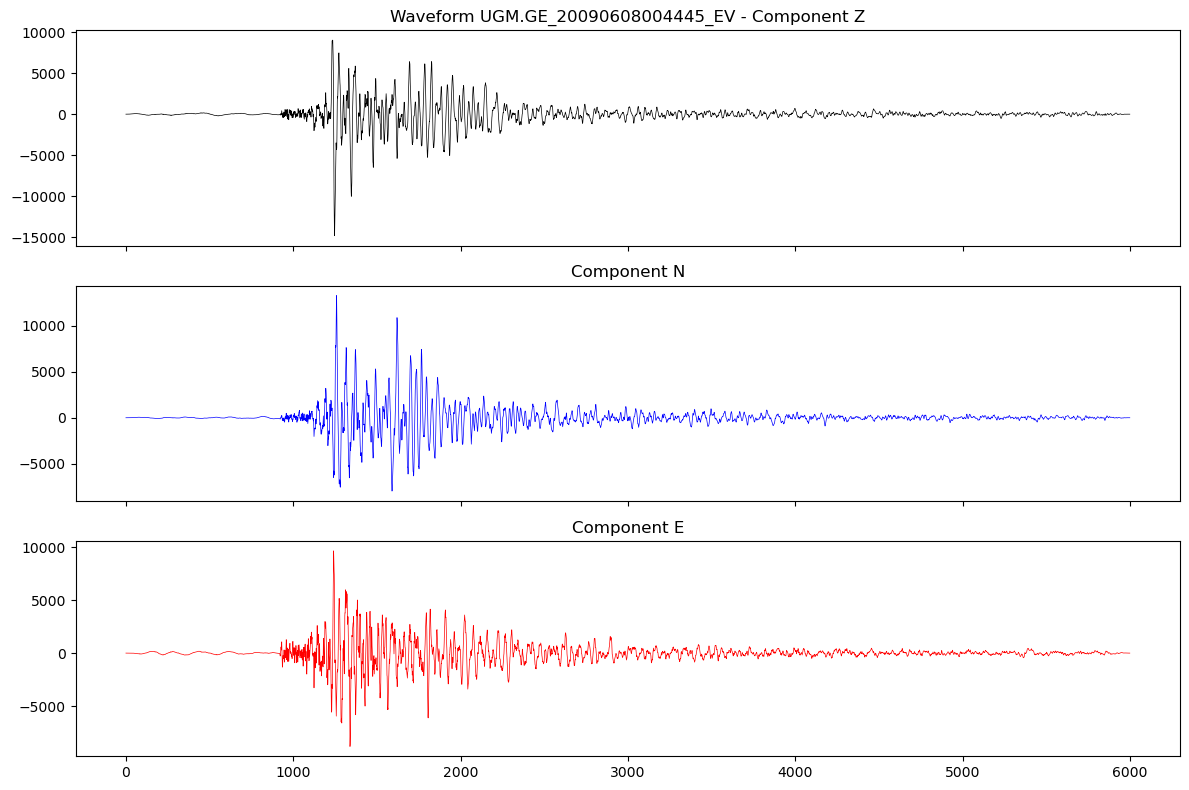

In [ ]:
import h5py
import matplotlib.pyplot as plt

# Pilih salah satu trace_name dari hasil match
target_trace = df_final_match.iloc[5]['trace_name']

with h5py.File(H5_STEAD, 'r') as f:
    dataset = f['data'][target_trace]
    data = np.array(dataset)
    
    # Plot 3 Komponen (Z, N, E)
    fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    ax[0].plot(data[:, 0], color='black', lw=0.5)
    ax[0].set_title(f"Waveform {target_trace} - Component Z")
    ax[1].plot(data[:, 1], color='blue', lw=0.5)
    ax[1].set_title("Component N")
    ax[2].plot(data[:, 2], color='red', lw=0.5)
    ax[2].set_title("Component E")
    
    plt.tight_layout()
    plt.show()

/opt/homebrew/Caskroom/miniforge/base/envs/seismik_env/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/seismik_env/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/seismik_env/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/seismik_env/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural

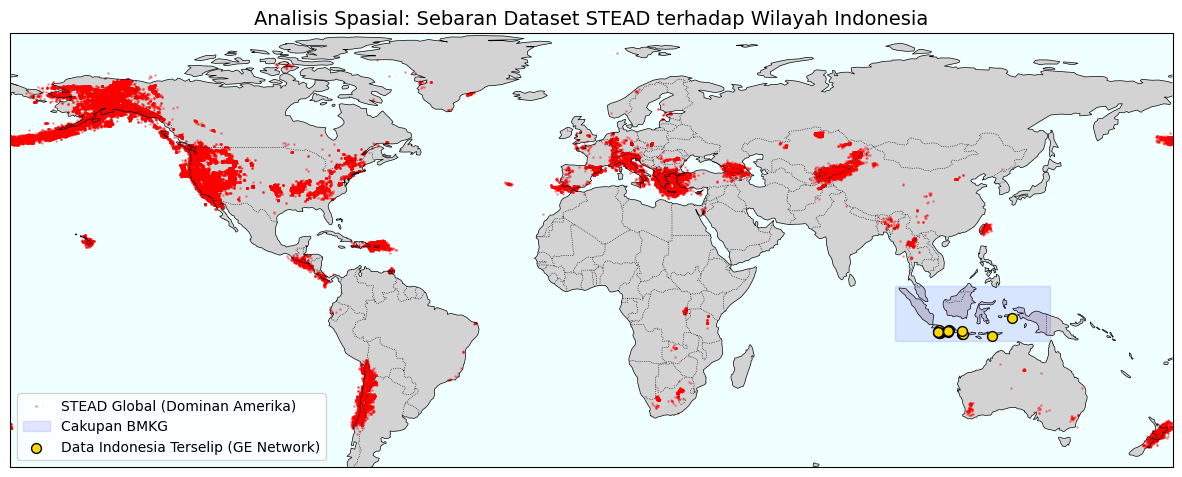

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_geographic_distribution(df_stead, df_bmkg, df_indo):
    fig = plt.figure(figsize=(15, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Menambahkan fitur peta
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='azure')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

    # 1. Plot seluruh data STEAD (Sampel Global)
    ax.scatter(df_stead['longitude'], df_stead['latitude'], 
               color='red', s=1, alpha=0.3, label='STEAD Global (Dominan Amerika)')
    
    # 2. Plot Area BMKG (Batas Indonesia)
    ax.add_patch(plt.Rectangle((94, -11), 48, 17, color='blue', 
                                 alpha=0.1, transform=ccrs.PlateCarree(), label='Cakupan BMKG'))
    
    # 3. Plot 17 Data Terselip (Harta Karun)
    ax.scatter(df_indo['source_longitude'], df_indo['source_latitude'], 
               color='gold', s=50, edgecolor='black', label='Data Indonesia Terselip (GE Network)', 
               transform=ccrs.PlateCarree(), zorder=5)

    ax.set_title("Analisis Spasial: Sebaran Dataset STEAD terhadap Wilayah Indonesia", fontsize=14)
    ax.legend(loc='lower left')
    plt.show()

# Panggil fungsi
plot_geographic_distribution(df_stead, df_bmkg, df_terselip)

Menghasilkan visualisasi ilmiah...


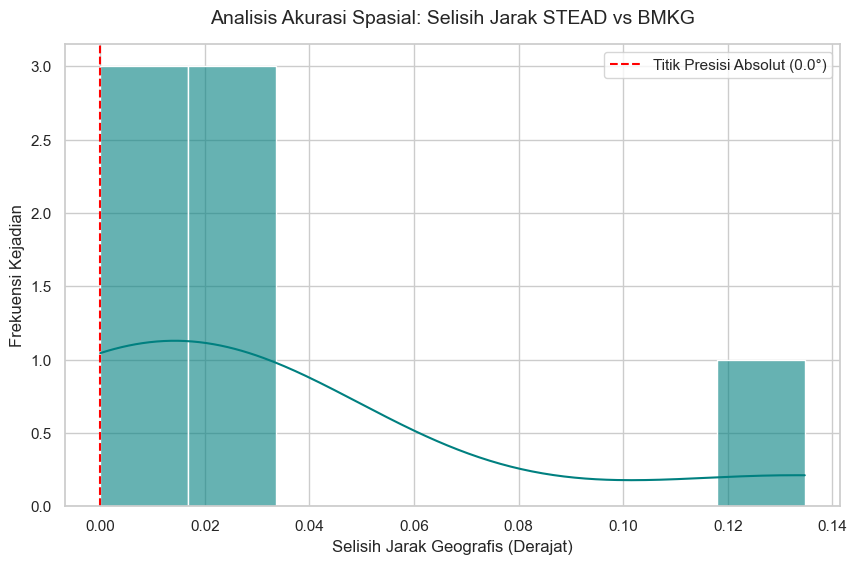

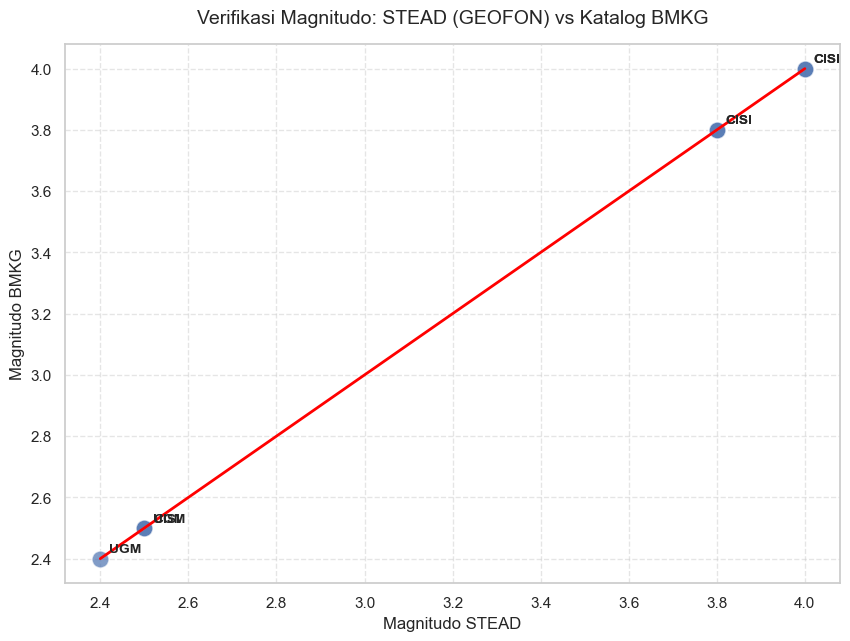

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Opsional: Agar tampilan grafik lebih profesional
sns.set_theme(style="whitegrid")
# --- FUNGSI 1: DISTRIBUSI PRESISI JARAK ---
def plot_distance_precision(df_matched):
    plt.figure(figsize=(10, 6))
    # sns sekarang sudah di-define di atas
    sns.histplot(df_matched['dist_diff'], bins=8, kde=True, color='teal', alpha=0.6)
    
    plt.axvline(x=0.0, color='red', linestyle='--', label='Titik Presisi Absolut (0.0°)')
    plt.title("Analisis Akurasi Spasial: Selisih Jarak STEAD vs BMKG", fontsize=14, pad=15)
    plt.xlabel("Selisih Jarak Geografis (Derajat)", fontsize=12)
    plt.ylabel("Frekuensi Kejadian", fontsize=12)
    plt.legend()
    plt.show()

# --- FUNGSI 2: KORELASI MAGNITUDO ---
def plot_magnitude_comparison(df_matched):
    plt.figure(figsize=(10, 7))
    
    # Plot regresi untuk melihat konsistensi data
    sns.regplot(data=df_matched, x='mag_stead', y='mag_bmkg', 
                scatter_kws={'s':150, 'alpha':0.7, 'edgecolor':'w'},
                line_kws={'color':'red', 'lw':2})
    
    # Menambahkan label teks untuk identitas stasiun
    for i, row in df_matched.iterrows():
        plt.text(row['mag_stead']+0.02, row['mag_bmkg']+0.02, 
                 f"{row['station']}", fontsize=10, weight='bold')

    plt.title("Verifikasi Magnitudo: STEAD (GEOFON) vs Katalog BMKG", fontsize=14, pad=15)
    plt.xlabel("Magnitudo STEAD", fontsize=12)
    plt.ylabel("Magnitudo BMKG", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- EKSEKUSI VISUALISASI ---
if 'df_final_match' in locals() and not df_final_match.empty:
    print("Menghasilkan visualisasi ilmiah...")
    plot_distance_precision(df_final_match)
    plot_magnitude_comparison(df_final_match)
else:
    print("Data df_final_match tidak ditemukan atau kosong. Pastikan proses matching sudah berhasil.")

Memproses Katalog BMKG...


/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_67692/182531454.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['dt'] = pd.to_datetime(df['dt_raw'], errors='coerce', utc=True)


Selesai: 0 kejadian ditemukan.

Memproses Katalog USGS...
Selesai: 79,061 kejadian ditemukan.



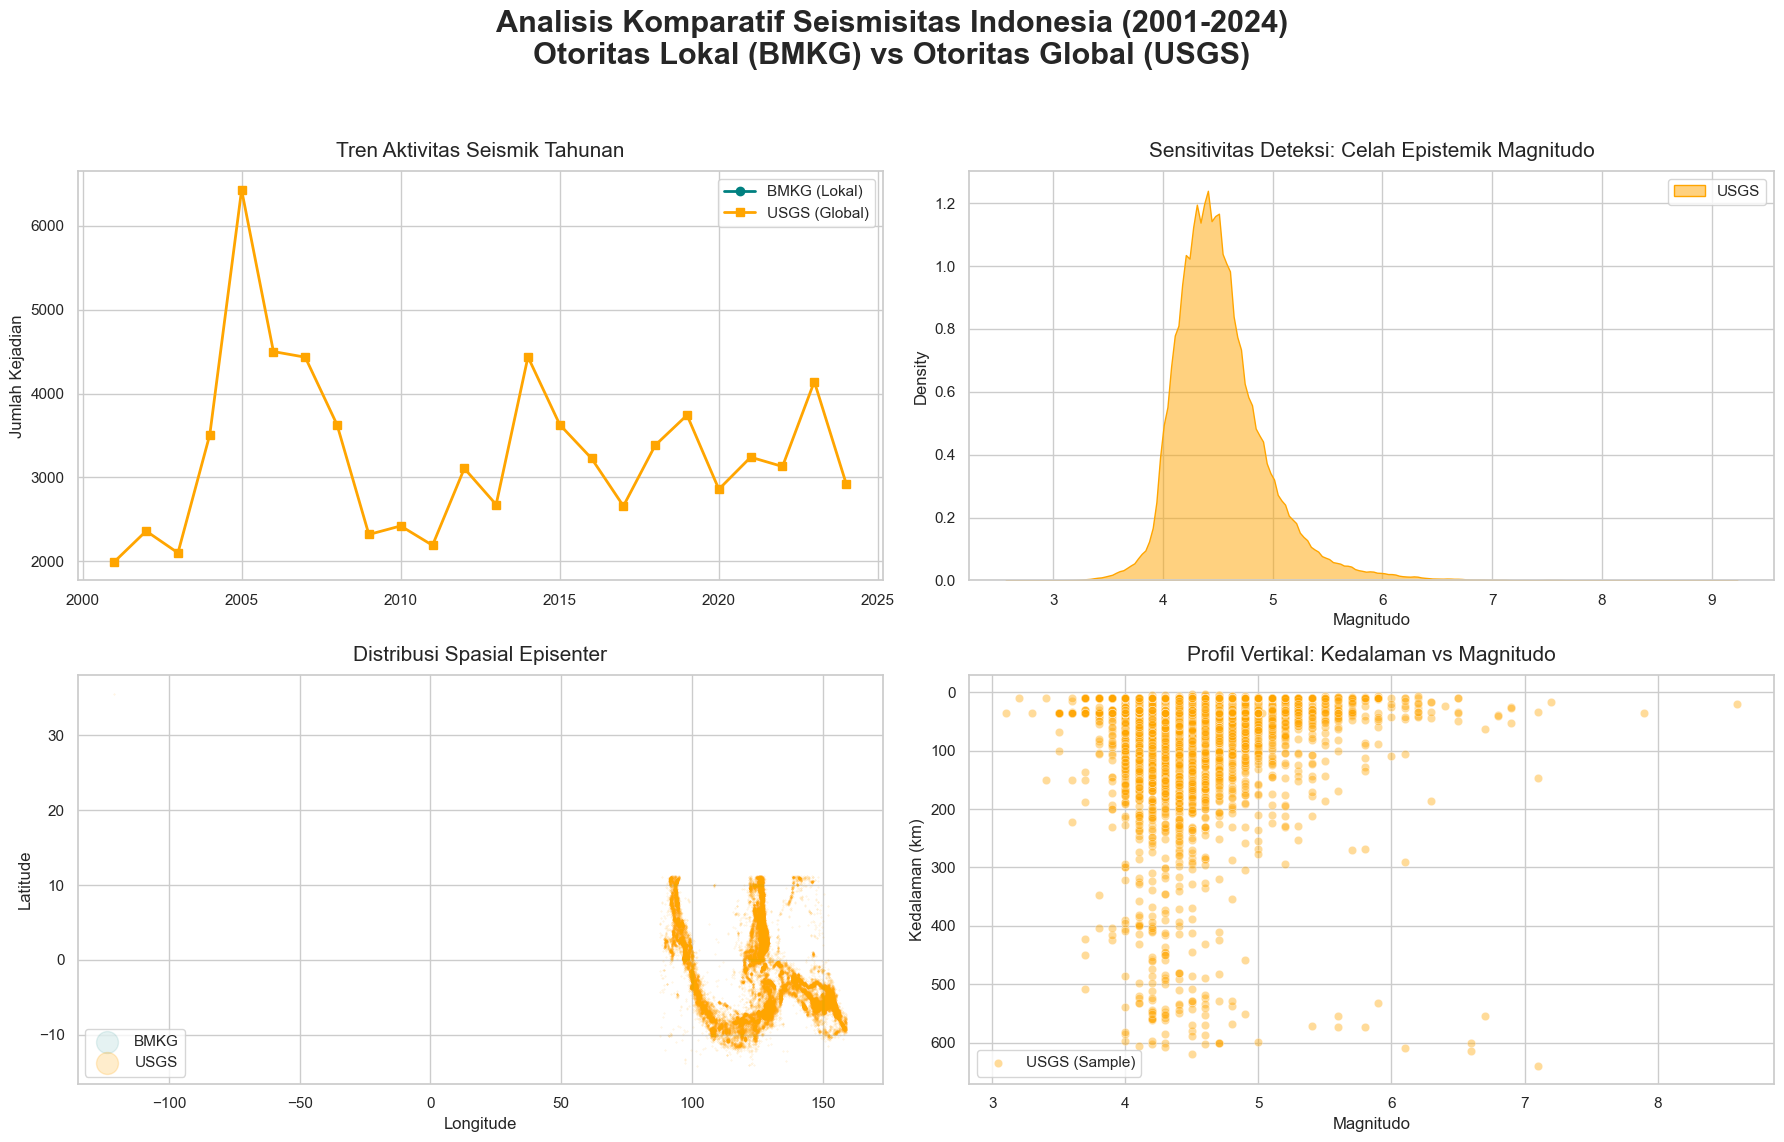

--- Ringkasan Statistik Akhir ---
Rasio Kelimpahan Data: 0.00x lipat mengungguli USGS.
Magnitudo Rata-rata BMKG: nan
Magnitudo Rata-rata USGS: 4.53


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. KONFIGURASI PATH ---
PATH_USGS = '/Volumes/Extreme SSD/benchmark_bmkg_indonesia/usgs_katalog/katalog_usgs_master_2001_2025.csv'
PATH_BMKG = '/Volumes/Extreme SSD/Indonesian Earthquake Catalog (BMKG), 1998–2024/BMKG_Earthquake_Catalog.csv'

# --- 2. FUNGSI PEMBERSIHAN & STANDARISASI ---
def standard_clean(df, name):
    print(f"Memproses Katalog {name}...")
    # Standarisasi nama kolom (lowercase, buang spasi & satuan)
    df.columns = [c.lower().split(' (')[0].strip() for c in df.columns]
    
    # Mapping kolom yang sering berbeda (USGS: mag, BMKG: magnitude)
    rename_dict = {}
    if 'mag' in df.columns and 'magnitude' not in df.columns:
        rename_dict['mag'] = 'magnitude'
    if 'time' in df.columns:
        rename_dict['time'] = 'dt_raw'
    elif 'datetime' in df.columns:
        rename_dict['datetime'] = 'dt_raw'
        
    df = df.rename(columns=rename_dict)
    
    # Konversi waktu ke datetime UTC
    df['dt'] = pd.to_datetime(df['dt_raw'], errors='coerce', utc=True)
    
    # Filter rentang waktu sinkron (2001 - 2024)
    start_date, end_date = '2001-01-01', '2024-12-31'
    df = df[(df['dt'] >= start_date) & (df['dt'] <= end_date)]
    
    # Hapus baris dengan nilai kosong pada parameter krusial
    required_cols = ['latitude', 'longitude', 'magnitude', 'depth', 'dt']
    df = df.dropna(subset=required_cols)
    
    print(f"Selesai: {len(df):,} kejadian ditemukan.\n")
    return df

# --- 3. EKSEKUSI PEMROSESAN DATA ---
try:
    df_bmkg_raw = pd.read_csv(PATH_BMKG)
    df_usgs_raw = pd.read_csv(PATH_USGS)

    df_bmkg = standard_clean(df_bmkg_raw, "BMKG")
    df_usgs = standard_clean(df_usgs_raw, "USGS")

    # --- 4. VISUALISASI DASHBOARD KOMPARATIF ---
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Analisis Komparatif Seismisitas Indonesia (2001-2024)\nOtoritas Lokal (BMKG) vs Otoritas Global (USGS)', 
                 fontsize=22, fontweight='bold', y=0.98)

    # A. Perbandingan Volume Tahunan (Time-Series)
    df_bmkg['year'] = df_bmkg['dt'].dt.year
    df_usgs['year'] = df_usgs['dt'].dt.year
    yearly_b = df_bmkg.groupby('year').size()
    yearly_u = df_usgs.groupby('year').size()
    
    axes[0,0].plot(yearly_b.index, yearly_b.values, label='BMKG (Lokal)', color='teal', marker='o', lw=2)
    axes[0,0].plot(yearly_u.index, yearly_u.values, label='USGS (Global)', color='orange', marker='s', lw=2)
    axes[0,0].set_title('Tren Aktivitas Seismik Tahunan', fontsize=15, pad=10)
    axes[0,0].set_ylabel('Jumlah Kejadian')
    axes[0,0].legend()

    # B. Analisis Kelengkapan Magnitudo (Magnitude of Completeness)
    sns.kdeplot(df_bmkg['magnitude'], fill=True, color='teal', label='BMKG', ax=axes[0,1], alpha=0.5)
    sns.kdeplot(df_usgs['magnitude'], fill=True, color='orange', label='USGS', ax=axes[0,1], alpha=0.5)
    axes[0,1].set_title('Sensitivitas Deteksi: Celah Epistemik Magnitudo', fontsize=15, pad=10)
    axes[0,1].set_xlabel('Magnitudo')
    axes[0,1].legend()

    # C. Sebaran Geografis (Point Distribution)
    axes[1,0].scatter(df_bmkg['longitude'], df_bmkg['latitude'], s=0.1, color='teal', alpha=0.1, label='BMKG')
    axes[1,0].scatter(df_usgs['longitude'], df_usgs['latitude'], s=0.1, color='orange', alpha=0.2, label='USGS')
    axes[1,0].set_title('Distribusi Spasial Episenter', fontsize=15, pad=10)
    axes[1,0].set_xlabel('Longitude')
    axes[1,0].set_ylabel('Latitude')
    lgnd = axes[1,0].legend(loc="lower left", markerscale=50)

    # D. Profil Kedalaman vs Magnitudo
    sns.scatterplot(data=df_bmkg.sample(min(5000, len(df_bmkg))), x='magnitude', y='depth', 
                    color='teal', alpha=0.2, ax=axes[1,1], label='BMKG (Sample)')
    sns.scatterplot(data=df_usgs.sample(min(5000, len(df_usgs))), x='magnitude', y='depth', 
                    color='orange', alpha=0.4, ax=axes[1,1], label='USGS (Sample)')
    axes[1,1].invert_yaxis()
    axes[1,1].set_title('Profil Vertikal: Kedalaman vs Magnitudo', fontsize=15, pad=10)
    axes[1,1].set_xlabel('Magnitudo')
    axes[1,1].set_ylabel('Kedalaman (km)')
    axes[1,1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- 5. RINGKASAN STATISTIK ---
    print("--- Ringkasan Statistik Akhir ---")
    print(f"Rasio Kelimpahan Data: {len(df_bmkg)/len(df_usgs):.2f}x lipat mengungguli USGS.")
    print(f"Magnitudo Rata-rata BMKG: {df_bmkg['magnitude'].mean():.2f}")
    print(f"Magnitudo Rata-rata USGS: {df_usgs['magnitude'].mean():.2f}")

except FileNotFoundError as e:
    print(f"Error: File tidak ditemukan. Pastikan SSD sudah terhubung. Detail: {e}")
except Exception as e:
    print(f"Terjadi kesalahan: {e}")

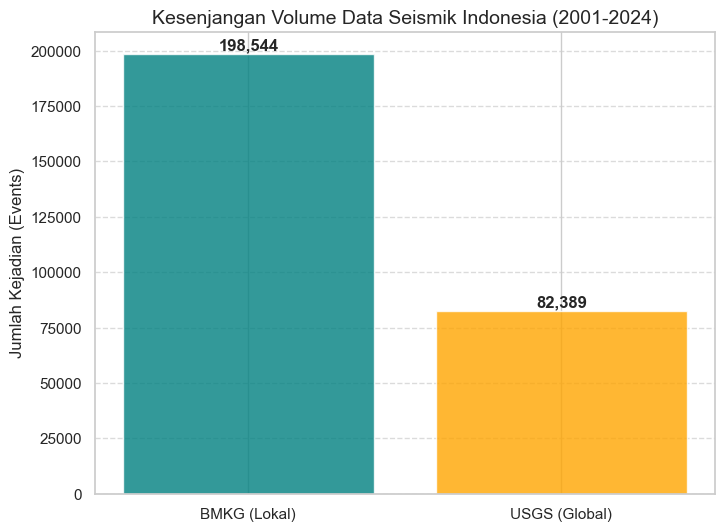

In [12]:
import matplotlib.pyplot as plt

labels = ['BMKG (Lokal)', 'USGS (Global)']
counts = [198544, 82389]
colors = ['teal', 'orange']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts, color=colors, alpha=0.8)
plt.title('Kesenjangan Volume Data Seismik Indonesia (2001-2024)', fontsize=14)
plt.ylabel('Jumlah Kejadian (Events)')

# Tambahkan label angka di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2000, f"{yval:,}", ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_67692/52303011.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled = df.resample('M', on='dt').size().reset_index(name='count')


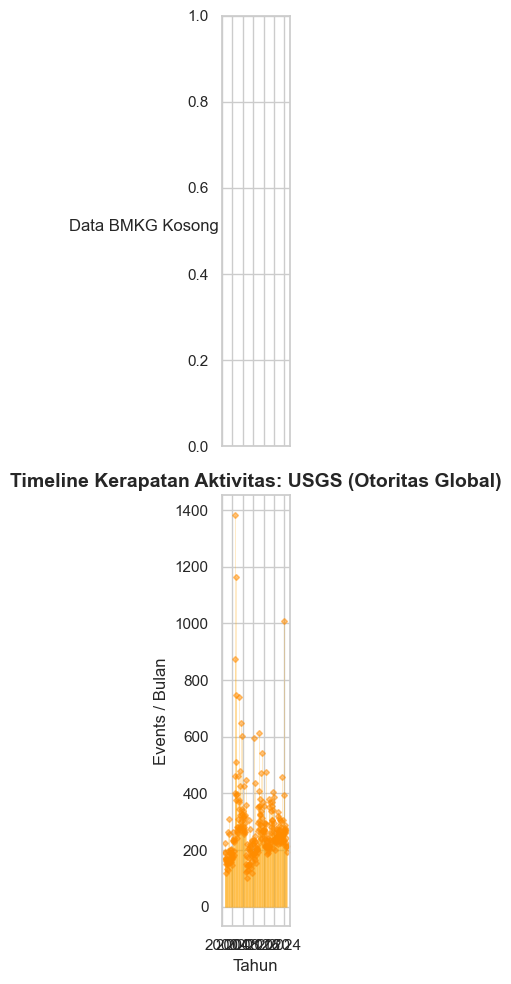

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def prepare_stem_data(df):
    if df.empty:
        return pd.DataFrame(columns=['dt', 'count'])
    # Resample bulanan untuk menghindari kepadatan visual (overplotting)
    resampled = df.resample('M', on='dt').size().reset_index(name='count')
    return resampled

# 1. Preparasi Data
df_b_stem = prepare_stem_data(df_bmkg)
df_u_stem = prepare_stem_data(df_usgs)

# 2. Visualisasi 2 Frame
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Plot BMKG (Frame Atas)
if not df_b_stem.empty:
    markerline, stemlines, baseline = axes[0].stem(df_b_stem['dt'], df_b_stem['count'], 
                                                  linefmt='teal', markerfmt='o', basefmt=" ")
    plt.setp(markerline, markersize=3, alpha=0.5)
    plt.setp(stemlines, linewidth=0.5, alpha=0.3)
    axes[0].set_title('Timeline Kerapatan Aktivitas: BMKG (Otoritas Lokal)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Events / Bulan')
else:
    axes[0].text(0.5, 0.5, 'Data BMKG Kosong', ha='center')

# Plot USGS (Frame Bawah)
if not df_u_stem.empty:
    markerline, stemlines, baseline = axes[1].stem(df_u_stem['dt'], df_u_stem['count'], 
                                                  linefmt='orange', markerfmt='D', basefmt=" ")
    plt.setp(markerline, markersize=3, alpha=0.5, color='darkorange')
    plt.setp(stemlines, linewidth=0.5, alpha=0.3, color='orange')
    axes[1].set_title('Timeline Kerapatan Aktivitas: USGS (Otoritas Global)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Events / Bulan')
else:
    axes[1].text(0.5, 0.5, 'Data USGS Kosong untuk Periode Ini', ha='center', color='red')

axes[1].set_xlabel('Tahun')
plt.tight_layout()
plt.show()